# Who Hunts Who?
## Comparing 4 Knowledge Graph Construction Methods for Predator–Prey Relations

### Goal
Build a predator–prey knowledge graph from ~20 Wikipedia animal pages and compare 4 extraction approaches:

1. **Method A – Co-occurrence**
2. **Method B – Dependency Patterns**
3. **Method C – OpenIE-style Relation Extraction**
4. **Combination of A,B and C**

All methods are evaluated against the same gold standard using Precision, Recall and F1.

---
## Section 0 – Setup & Imports

In [384]:
# 0.1  Install dependencies (run once; comment out after first execution) - activate your virtual environment before running this cell.
# After running this cell for the first time, restart the kernel and comment these lines out.
#!pip install -q wikipedia-api spacy networkx pandas matplotlib seaborn
#!python -m spacy download en_core_web_md -q

In [385]:
#!pip install nltk

In [386]:
# 0.2 Imports
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
import spacy
import wikipediaapi


pd.set_option("display.max_colwidth", 120)
%matplotlib inline
print("Imports loaded.")

Imports loaded.


---
## Utils

Shared helpers used by every extraction method below: graph plotting, sentence preprocessing, predation-keyword matching, and WordNet-based category expansion (e.g. knowing a *fly* is an *insect* so "Frog eats insects" implies Frog -> Fly).


In [387]:
def show_foodnet_plot(df, edges, title=None):
    """Plot a predator-prey graph from `edges`; optionally show a summary `df` and a `title`."""
    if df is not None:
        display(df)
    plt.figure(figsize=(16, 12))
    g = nx.DiGraph()
    g.add_edges_from(edges)
    pos = nx.spring_layout(g, seed=42, k=1.5, iterations=100)
    nx.draw(g, pos, with_labels=True, node_size=1200, font_size=11, arrows=True)
    if title:
        plt.title(title, fontsize=14)
    plt.show()


In [388]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andiw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andiw\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [389]:
from nltk.corpus import wordnet as wn
from functools import lru_cache

In [390]:
@lru_cache(maxsize=10000)
def get_category(entity):
    """Return a broad biological category for an entity via WordNet.

    This lets the extraction methods generalize: if a page says "Frog eats
    insects", we can still infer Frog -> Fly, since a fly is an insect.
    """
    if not entity:
        return None

    normalized = entity.strip().lower()
    try:
        synsets = wn.synsets(normalized, pos=wn.NOUN)
    except LookupError:
        return None
    if not synsets:
        return None

    path = synsets[0].hypernym_paths()[0] if synsets[0].hypernym_paths() else []
    if not path:
        return None

    broad = {"animal", "mammal", "bird", "fish", "insect", "reptile", "amphibian"}
    for h in reversed(path):
        name = h.name().split(".")[0]
        if name in broad:
            return name
    return path[-1].name().split(".")[0]

CATEGORY_ALIASES = {
    "insect": {"insect", "insects", "bug", "bugs"},
    "fish": {"fish", "fishes"},
    "bird": {"bird", "birds"},
    "mammal": {"mammal", "mammals"},
    "reptile": {"reptile", "reptiles"},
    "amphibian": {"amphibian", "amphibians"},
}

MANUAL_CATEGORY_OVERRIDE = {
    "cricket": "insect", "fly": "insect", "spider": "insect", "beetle": "insect", "grasshopper": "insect", "caterpillar": "insect",
    "salamander": "amphibian", "lizard": "reptile",
    "eagle": "bird", "hawk": "bird", "barn owl": "bird", "rabbit": "mammal", "mouse": "mammal", "weasel": "mammal",
}


PREDATION_KEYWORDS = {
    "eat", "eats", "ate", "eaten", "eating", "feeding", "feeds", "feed", "fed", "hunt", "hunts", "hunted", "hunting",
    "consume", "consumes", "consumed", "consuming", "devour", "devours", "devoured", "devouring",
    "predate", "predates", "predated", "predating", "prey", "preys",
    "attack", "attacks", "attacked", "attacking", "kill", "kills", "killed", "killing",
    "stalk", "stalks", "stalked", "stalking", "chase", "chases", "chased", "chasing",
    "pursue", "pursues", "pursued", "pursuing", "capture", "captures", "captured", "capturing", "overpower"
}

PREDATION_PHRASES = {
    "feeds on", "preys on", "preyed on", "feeds", "feed", "fed", "hunt", "hunts", "eat", "eats", "consumes", "eats on", "eating on",
    "hunts for", "hunting for", "feeds upon", "preys upon", "prey upon", "predate", "predates", "prey", "preys",
    "attacks", "chases", "stalks", "captures", "kills", "kill", "devours", "consumes", "pursues", "diet consists"
}

PREDATION_PASSIVE_PHRASES = {
    "is eaten by", "are eaten by", "is hunted by", "are hunted by", "is killed by",
    "are killed by", "is attacked by", "are attacked by", "is consumed by", "are consumed by",
    "is a predator of", "are predators of", "feeds", "hunted by", "killed by",
}

TAXONOMY_CUES = {"family", "genus", "species", "order", "class", "clade"}

NEGATIVE_PREDATION_PATTERNS = {
    "does not eat", "doesn't eat", "did not eat", "never eats", "never ate", "not eaten",
    "is not a predator", "are not predators", "not preyed on", "not hunted", "not eaten", "not consumed",
}

NOISY_CONTEXT_PATTERNS = {
    "food chain", "food web", "such as", "including", "e.g.", "for example", "examples of", "types of", "includes", "like",
}


def split_sentences(text):
    return [s for s in re.split(r"(?<=[.!?])\s+", preprocess_text(text) or "") if s.strip()]


def _entity_regex(entity):
    variants = sorted(get_entity_variants(entity), key=len, reverse=True)
    return r"(?:" + "|".join(re.escape(v) for v in variants) + r")"


def get_alias_to_category_map():
    return {
        alias: category
        for category, aliases in CATEGORY_ALIASES.items()
        for alias in aliases
    }


def build_category_to_animals(all_animals):
    category_to_animals = {}
    for animal in all_animals:
        cat = MANUAL_CATEGORY_OVERRIDE.get(animal.lower()) or get_category(animal)
        if cat:
            category_to_animals.setdefault(cat.lower(), set()).add(animal)
    return category_to_animals


def sentence_has_predation_cue(sentence_lower):
    return any(p in sentence_lower for p in PREDATION_PHRASES) or any(w in sentence_lower for w in PREDATION_KEYWORDS)


def detect_categories_in_sentence(sentence_lower):
    alias_to_category = get_alias_to_category_map()
    return {category for alias, category in alias_to_category.items() if alias in sentence_lower}


def is_negated_predation(sentence_lower):
    return any(pattern in sentence_lower for pattern in NEGATIVE_PREDATION_PATTERNS)


def entity_positions(sentence_lower, entity):
    positions = []
    for variant in get_entity_variants(entity):
        for m in re.finditer(rf"\b{re.escape(variant)}\b", sentence_lower):
            positions.append(m.start())
    return sorted(positions)


def is_predation_statement(sentence_lower, source=None, prey=None):
    if is_taxonomy_statement(sentence_lower):
        return False
    if is_negated_predation(sentence_lower):
        return False
    if any(pattern in sentence_lower for pattern in NOISY_CONTEXT_PATTERNS) and not any(phrase in sentence_lower for phrase in PREDATION_PHRASES):
        return False
    if not sentence_has_predation_cue(sentence_lower):
        return False
    if source and prey:
        if not mentions_entity(sentence_lower, source) or not mentions_entity(sentence_lower, prey):
            return False
        src_positions = entity_positions(sentence_lower, source)
        prey_positions = entity_positions(sentence_lower, prey)
        if not src_positions or not prey_positions:
            return False
        if min(src_positions) > max(prey_positions):
            return bool(PASSIVE_REGEX.search(sentence_lower) or " by " in sentence_lower)
    return True


def is_taxonomy_statement(sentence_lower):
    return (
        "bird of prey" in sentence_lower
        or "birds of prey" in sentence_lower
        or any(cue in sentence_lower for cue in TAXONOMY_CUES)
    )


def add_non_self_edge(edges, predator, prey):
    if predator.lower() != prey.lower():
        edges.add((predator, prey))


def sanitize_edges(edges, source_set, target_set, all_animals, allowed_targets_by_source=None):
    """Hard constraint: only original-list nodes, valid direction, and optional per-source targets."""
    allowed = set(all_animals)
    cleaned = {
        (s, t)
        for s, t in edges
        if s in allowed and t in allowed and s in source_set and t in target_set and s != t
    }
    if allowed_targets_by_source is None:
        return cleaned
    return {
        (s, t)
        for s, t in cleaned
        if s in allowed_targets_by_source and t in allowed_targets_by_source[s]
    }


def expand_category_mentions(
    sentence_lower,
    predator,
    all_animals,
    category_to_animals,
    allowed_categories=None,
    source_allowlist=None,
):
    """Expand category mentions to concrete prey nodes with optional filters."""
    if source_allowlist is not None and predator not in source_allowlist:
        return set()

    detected = detect_categories_in_sentence(sentence_lower)
    if allowed_categories is not None:
        allowed_categories = set(allowed_categories)
        detected = {c for c in detected if c in allowed_categories}

    expanded = set()
    for category in detected:
        for prey in category_to_animals.get(category, set()):
            if prey in all_animals and prey.lower() != predator.lower():
                expanded.add(prey)
    return expanded


def balanced_category_expansion(
    sentence_lower,
    predator,
    all_animals_set,
    category_to_animals,
    allowed_categories=None,
    source_allowlist=None,
):
    """Generic balanced category expansion helper used by methods A/B/C."""
    return expand_category_mentions(
        sentence_lower,
        predator,
        all_animals_set,
        category_to_animals,
        allowed_categories=allowed_categories,
        source_allowlist=source_allowlist,
    )


print("Category utilities ready.")

Category utilities ready.


In [391]:
def get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY):
    """Return global source and target constraints for predator->prey extraction."""
    source_set = set(PREDATORS + MID_LEVEL)
    target_set = set(MID_LEVEL + PREY)
    return source_set, target_set

def get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY):
    """Precision-oriented constraints per source node.

    - Top predators can target MID_LEVEL and PREY
    - Mid-level predators can target PREY only
    """
    allowed = {}
    for src in PREDATORS:
        allowed[src] = set(MID_LEVEL + PREY)
    for src in MID_LEVEL:
        allowed[src] = set(PREY)
    return allowed

In [392]:
IRREGULAR_ENTITY_VARIANTS = {
    "mouse": {"mouse", "mice"},
    "fly": {"fly", "flies"},
    "wolf": {"wolf", "wolves"},
    "fox": {"fox", "foxes"},
    "bird": {"bird", "birds"},
}

def get_entity_variants(entity):
    e = entity.lower()
    variants = set(IRREGULAR_ENTITY_VARIANTS.get(e, {e}))
    if e not in IRREGULAR_ENTITY_VARIANTS:
        if e.endswith("y") and len(e) > 1 and e[-2] not in "aeiou":
            variants.add(e[:-1] + "ies")
        elif e.endswith(("s", "x", "z", "ch", "sh")):
            variants.add(e + "es")
        else:
            variants.add(e + "s")
    return variants

def mentions_entity(sentence_lower, entity):
    return any(
        re.search(rf"\b{re.escape(variant)}\b", sentence_lower)
        for variant in get_entity_variants(entity)
    )

def extract_edges_from_text(source, text, target_set, all_animals_set, category_to_animals, use_category_expansion=True):
    """Shared sentence extractor used by Methods A and C."""
    edges = set()
    for sent in split_sentences(text):
        s_lower = sent.lower()
        if not mentions_entity(s_lower, source):
            continue
        if is_taxonomy_statement(s_lower):
            continue
        if not sentence_has_predation_cue(s_lower):
            continue

        for prey in target_set:
            if mentions_entity(s_lower, prey):
                add_non_self_edge(edges, source, prey)

        if use_category_expansion:
            expanded = expand_category_mentions(
                s_lower, source, all_animals_set, category_to_animals
            )
            for prey in expanded:
                if prey in target_set:
                    add_non_self_edge(edges, source, prey)
    return edges

---
## Section 1 – Dataset

A controlled corpus of ~20 Wikipedia animal pages forming a simple terrestrial food web. The corpus contains predators, intermediate species and common prey to allow multi-hop chains.


In [393]:
# 1.1  Animal lists and Wikipedia page title mapping

PREDATORS = ["Hawk", "Eagle", "Barn Owl", "Fox", "Wolf", "Weasel"]

MID_LEVEL = ["Salamander", "Lizard", "Spider", "Bat"]

PREY = ["Mouse", "Rabbit", "Squirrel", "Grasshopper", "Cricket", "Caterpillar", "Fly", "Beetle"]

ALL_ANIMALS = PREDATORS + MID_LEVEL + PREY

# Map animal label → exact Wikipedia page title.
# Most match directly; override here where the general page title differs.
WIKI_PAGE_MAP = {
    "Hawk":        "Hawk",
    "Eagle":       "Eagle",
    "Barn Owl":    "Barn owl",
    "Fox":         "Fox",
    "Wolf":        "Wolf",
    "Weasel":      "Weasel",
    "Salamander":  "Salamander",
    "Lizard":      "Lizard",
    "Spider":      "Spider",
    "Bat":         "Bat",
    "Mouse":       "Mouse",
    "Rabbit":      "Rabbit",
    "Squirrel":    "Squirrel",
    "Grasshopper": "Grasshopper",
    "Cricket":     "Cricket (insect)",   # disambiguation: cricket sport vs insect
    "Caterpillar": "Caterpillar",
    "Fly":         "Fly",
    "Beetle":      "Beetle",
}

# Trophic colour map — used later for graph visualisations
TROPHIC_COLOR = {
    animal: color
    for animals, color in [
        (PREDATORS, "#e05c5c"),   # red   – top predators
        (MID_LEVEL, "#f0a500"),   # amber – mid-level
        (PREY,      "#4da06d"),   # green – lower trophic
    ]
    for animal in animals
}

print(f"Animal corpus: {len(ALL_ANIMALS)} animals total")
print(f"  Predators : {PREDATORS}")
print(f"  Mid-level : {MID_LEVEL}")
print(f"  Prey      : {PREY}")

Animal corpus: 18 animals total
  Predators : ['Hawk', 'Eagle', 'Barn Owl', 'Fox', 'Wolf', 'Weasel']
  Mid-level : ['Salamander', 'Lizard', 'Spider', 'Bat']
  Prey      : ['Mouse', 'Rabbit', 'Squirrel', 'Grasshopper', 'Cricket', 'Caterpillar', 'Fly', 'Beetle']


### 1.2 Fetching Wikipedia Pages

For each animal we retrieve:
- **Full plain text** of the page (for Methods A and B)
- **Internal wikilinks** (list of pages linked from this page, for Method C)

Pages are fetched once and cached locally (as a dict or JSON file) to avoid repeated API calls during development.

In [394]:
# 1.2 Fetch and cache Wikipedia pages
CACHE_PATH = Path("corpus_cache.json")

def fetch_corpus(page_map: dict, force_refresh: bool = False, allow_bootstrap_fallback: bool = True) -> dict:
    """Fetch Wikipedia pages, prefer cache when present."""
    corpus = {}
    if CACHE_PATH.exists() and not force_refresh:
        print(f"Loading corpus from cache: {CACHE_PATH}")
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            corpus = json.load(f)

        missing = [a for a in page_map if a not in corpus or not corpus[a].get("text")]
        if not missing:
            return corpus
        print(f"Cache missing {len(missing)} pages: {missing}. Fetching missing pages...")
    else:
        print("Fetching pages from Wikipedia API...")

    wiki = wikipediaapi.Wikipedia(
        language="en",
        user_agent="NLP-MAI-SS2026/1.0 (university project; contact: student@example.com)",
    )

    try:
        for animal, title in page_map.items():
            if animal in corpus and not force_refresh and corpus[animal].get("text"):
                continue
            page = wiki.page(title)
            if not page.exists():
                print(f"Warning: page not found for '{animal}' (title '{title}').")
                continue
            corpus[animal] = {
                "title": page.title,
                "url": page.fullurl,
                "text": page.text,
                "links": list(page.links.keys()),
            }
            print(f"Loaded {animal:15s} ({len(page.text):,} chars, {len(page.links)} links)")

        with open(CACHE_PATH, "w", encoding="utf-8") as f:
            json.dump(corpus, f, ensure_ascii=False, indent=2)
        print(f"Corpus cached to {CACHE_PATH}")
        return corpus

    except Exception as err:
        print(f"Wikipedia fetch failed: {type(err).__name__}: {err}")
        if CACHE_PATH.exists():
            print(f"Falling back to existing cache: {CACHE_PATH}")
            with open(CACHE_PATH, "r", encoding="utf-8") as f:
                return json.load(f)
        raise


wiki_corpus = fetch_corpus(WIKI_PAGE_MAP, force_refresh=False)


def preprocess_text(text: str) -> str:
    text = text or ""
    text = re.sub(r"\s*\[[^\]]*\]", " ", text)
    text = re.sub(r"\s*\([^)]*\)", " ", text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_sentences(text: str):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", preprocess_text(text)) if s.strip()]


def normalize_wiki_corpus(corpus: dict) -> dict:
    for animal, page in corpus.items():
        page["clean_text"] = preprocess_text(page.get("text", ""))
        page["sentences"] = get_sentences(page["clean_text"])
    return corpus


wiki_corpus = normalize_wiki_corpus(wiki_corpus)
print("Corpus preprocessing complete. Sentence counts:")
print({animal: len(data["sentences"]) for animal, data in wiki_corpus.items()})

Loading corpus from cache: corpus_cache.json
Corpus preprocessing complete. Sentence counts:
{'Hawk': 98, 'Eagle': 197, 'Fox': 156, 'Wolf': 486, 'Lizard': 272, 'Spider': 370, 'Bat': 413, 'Mouse': 71, 'Rabbit': 340, 'Squirrel': 113, 'Grasshopper': 246, 'Cricket': 203, 'Fly': 290, 'Beetle': 507, 'Caterpillar': 133, 'Barn Owl': 4, 'Weasel': 55, 'Salamander': 363}


### 1.3 Corpus Inspection

Quick sanity check: print page lengths and a sample sentence from each page to confirm the data looks as expected.

In [395]:
# 1.3  Corpus inspection — page lengths and a sample sentence per animal

rows = []
for animal, data in wiki_corpus.items():
    sentences = data.get("sentences", [])
    snippet = next(
        (s for s in sentences if animal.lower() in s.lower()),
        sentences[0] if sentences else "(no text)"
    )
    rows.append({
        "animal":     animal,
        "trophic":    "predator" if animal in PREDATORS else ("mid" if animal in MID_LEVEL else "prey"),
        "chars":      len(data.get("clean_text", data.get("text", ""))),
        "n_links":    len(data["links"]),
        "url":        data["url"],
        "snippet":    snippet[:200] + ("..." if len(snippet) > 200 else ""),
    })

corpus_df = pd.DataFrame(rows).sort_values(["trophic", "animal"]).reset_index(drop=True)
display(corpus_df[["animal", "trophic", "chars", "n_links", "snippet"]])

,animal,trophic,chars,n_links,snippet
0,Bat,mid,48545,451,"Bats are winged mammals, the only mammals capable of true and sustained flight."
1,Lizard,mid,27215,364,"Lizard is the common name used for all squamate reptiles other than snakes , encompassing over 7,000 species, rangin..."
2,Salamander,mid,47212,472,"Salamanders are a group of amphibians typically characterized by their lizard-like appearance, with slender bodies, ..."
3,Spider,mid,54146,623,"Spiders are air-breathing arthropods that have eight limbs, chelicerae with fangs generally able to inject venom, an..."
4,Barn Owl,predator,1063,18,"The barn owls, owls in the genus Tyto, are the most widely distributed genus of owls in the world."
5,Eagle,predator,20329,316,Eagle is the common name for certain large birds of prey within the family of the Accipitridae.
6,Fox,predator,16036,581,Foxes are small-to-medium-sized omnivorous mammals belonging to several genera of the family Canidae.
7,Hawk,predator,9932,127,Hawks are birds of prey of the family Accipitridae.
8,Weasel,predator,6453,738,Weasels are mammals of the genus Mustela of the family Mustelidae.
9,Wolf,predator,55044,1150,"The wolf , also known as the grey wolf or gray wolf, is a canine native to Eurasia and North America."


### 1.4 Debug: Corpus Health Check

Verifies that every animal in `ALL_ANIMALS` was fetched successfully, that no page is suspiciously short, and that the link lists are populated. This cell is safe to re-run at any time.

In [396]:
# 1.4 Corpus health check
MIN_TEXT_CHARS = 500
MIN_LINK_COUNT = 5

issues = []
ok_count = 0

print("=" * 60)
print(f"Corpus health check ({len(ALL_ANIMALS)} animals expected)")
print("=" * 60)

for animal in ALL_ANIMALS:
    if animal not in wiki_corpus:
        msg = f"MISSING  {animal:15s}  page not fetched"
        print(msg)
        issues.append(msg)
        continue

    data = wiki_corpus[animal]
    chars = len(data["text"])
    nlinks = len(data["links"])
    animal_issues = []

    if chars < MIN_TEXT_CHARS:
        animal_issues.append(f"text too short ({chars})")
    if nlinks < MIN_LINK_COUNT:
        animal_issues.append(f"few links ({nlinks})")

    if animal_issues:
        msg = f"WARN     {animal:15s}  {'; '.join(animal_issues)}"
        print(msg)
        issues.append(msg)
    else:
        print(f"OK       {animal:15s}  {chars:>8,} chars   {nlinks:>4} links")
        ok_count += 1

print("=" * 60)
print(f"Result: {ok_count}/{len(ALL_ANIMALS)} pages passed checks.")
if issues:
    print(f"Issues found: {len(issues)}")
else:
    print("All pages look good.")

Corpus health check (18 animals expected)
OK       Hawk               10,341 chars    127 links
OK       Eagle              21,402 chars    316 links
OK       Barn Owl            1,065 chars     18 links
OK       Fox                16,959 chars    581 links
OK       Wolf               56,540 chars   1150 links
OK       Weasel              6,838 chars    738 links
OK       Salamander         48,765 chars    472 links
OK       Lizard             28,181 chars    364 links
OK       Spider             55,392 chars    623 links
OK       Bat                50,398 chars    451 links
OK       Mouse               7,955 chars    130 links
OK       Rabbit             40,958 chars    745 links
OK       Squirrel           13,401 chars    652 links
OK       Grasshopper        30,758 chars    385 links
OK       Cricket            26,234 chars    353 links
OK       Caterpillar        16,177 chars    211 links
OK       Fly                35,324 chars    721 links
OK       Beetle             64,770 chars

---
## Section 2 – Gold Standard

We define a small reference dataset to evaluate

### Construction Rules
- Manually curated list of predator-prey

### Example
| Predator | Prey | Evidence |
|-----------|------|----------|
| Fox | Rabbit | "Foxes feed on rabbits..." |
| Owl | Mouse | "Owls prey on mice..." |

This gold standard serves as the single reference set used to evaluate all three methods. Using a predefined benchmark improves reproducibility and ensures a fair comparison across approaches.


In [397]:
# Gold standard predator->prey relations (manually curated)
gold_standard = [
    # Barn Owl
    {'predator':'Barn Owl','prey':'Beetle'},
    {'predator':'Barn Owl','prey':'Grasshopper'},
    {'predator':'Barn Owl','prey':'Mouse'},

    # Bat
    {'predator':'Bat','prey':'Beetle'},
    {'predator':'Bat','prey':'Caterpillar'},
    {'predator':'Bat','prey':'Cricket'},
    {'predator':'Bat','prey':'Fly'},
    {'predator':'Bat','prey':'Grasshopper'},

    # Eagle
    {'predator':'Eagle','prey':'Rabbit'},
    {'predator':'Eagle','prey':'Squirrel'},

    # Fox
    {'predator':'Fox','prey':'Mouse'},
    {'predator':'Fox','prey':'Rabbit'},

    # Hawk
    {'predator':'Hawk','prey':'Lizard'},
    {'predator':'Hawk','prey':'Mouse'},
    {'predator':'Hawk','prey':'Rabbit'},
    {'predator':'Hawk','prey':'Squirrel'},

    # Lizard
    {'predator':'Lizard','prey':'Beetle'},
    {'predator':'Lizard','prey':'Caterpillar'},
    {'predator':'Lizard','prey':'Cricket'},
    {'predator':'Lizard','prey':'Fly'},
    {'predator':'Lizard','prey':'Grasshopper'},

    # Salamander
    {'predator':'Salamander','prey':'Beetle'},
    {'predator':'Salamander','prey':'Caterpillar'},
    {'predator':'Salamander','prey':'Cricket'},
    {'predator':'Salamander','prey':'Fly'},
    {'predator':'Salamander','prey':'Grasshopper'},

    # Spider
    {'predator':'Spider','prey':'Beetle'},
    {'predator':'Spider','prey':'Caterpillar'},
    {'predator':'Spider','prey':'Cricket'},
    {'predator':'Spider','prey':'Fly'},
    {'predator':'Spider','prey':'Grasshopper'},

    # Weasel
    {'predator':'Weasel','prey':'Mouse'},
    {'predator':'Weasel','prey':'Rabbit'},
    {'predator':'Weasel','prey':'Squirrel'},

    # Wolf
    {'predator':'Wolf','prey':'Mouse'},
    {'predator':'Wolf','prey':'Rabbit'},
]

In [398]:
gold_df = pd.DataFrame(gold_standard)
gold_edges = set(zip(gold_df.predator, gold_df.prey))

# Reconcile dataset with gold-standard animal universe.
gold_animals = sorted(set(gold_df['predator']).union(set(gold_df['prey'])))
old_all_animals = set(ALL_ANIMALS)

PREDATORS = [a for a in PREDATORS if a in gold_animals]
MID_LEVEL = [a for a in MID_LEVEL if a in gold_animals]
PREY = [a for a in PREY if a in gold_animals]
ALL_ANIMALS = PREDATORS + MID_LEVEL + PREY

WIKI_PAGE_MAP = {k: v for k, v in WIKI_PAGE_MAP.items() if k in ALL_ANIMALS}
TROPHIC_COLOR = {k: v for k, v in TROPHIC_COLOR.items() if k in ALL_ANIMALS}
wiki_corpus = {k: v for k, v in wiki_corpus.items() if k in ALL_ANIMALS}

# Persist aligned corpus to cache so future runs stay consistent.
with open(CACHE_PATH, 'w', encoding='utf-8') as f:
    json.dump(wiki_corpus, f, ensure_ascii=False, indent=2)

removed_animals = sorted(old_all_animals - set(ALL_ANIMALS))
print('Gold-aligned animal universe:', ALL_ANIMALS)
print('Removed from dataset because not in gold:', removed_animals)
print(f'Updated cache at {CACHE_PATH} with {len(wiki_corpus)} animals.')

gold_df.head()

Gold-aligned animal universe: ['Hawk', 'Eagle', 'Barn Owl', 'Fox', 'Wolf', 'Weasel', 'Salamander', 'Lizard', 'Spider', 'Bat', 'Mouse', 'Rabbit', 'Squirrel', 'Grasshopper', 'Cricket', 'Caterpillar', 'Fly', 'Beetle']
Removed from dataset because not in gold: []
Updated cache at corpus_cache.json with 18 animals.


,predator,prey
0,Barn Owl,Beetle
1,Barn Owl,Grasshopper
2,Barn Owl,Mouse
3,Bat,Beetle
4,Bat,Caterpillar


### 2.2 Gold Standard Summary

Display the full gold standard table and a small network visualisation of the true food web.

,predator,prey
0,Barn Owl,Beetle
1,Barn Owl,Grasshopper
2,Barn Owl,Mouse
3,Bat,Beetle
4,Bat,Caterpillar
5,Bat,Cricket
6,Bat,Fly
7,Bat,Grasshopper
8,Eagle,Rabbit
9,Eagle,Squirrel


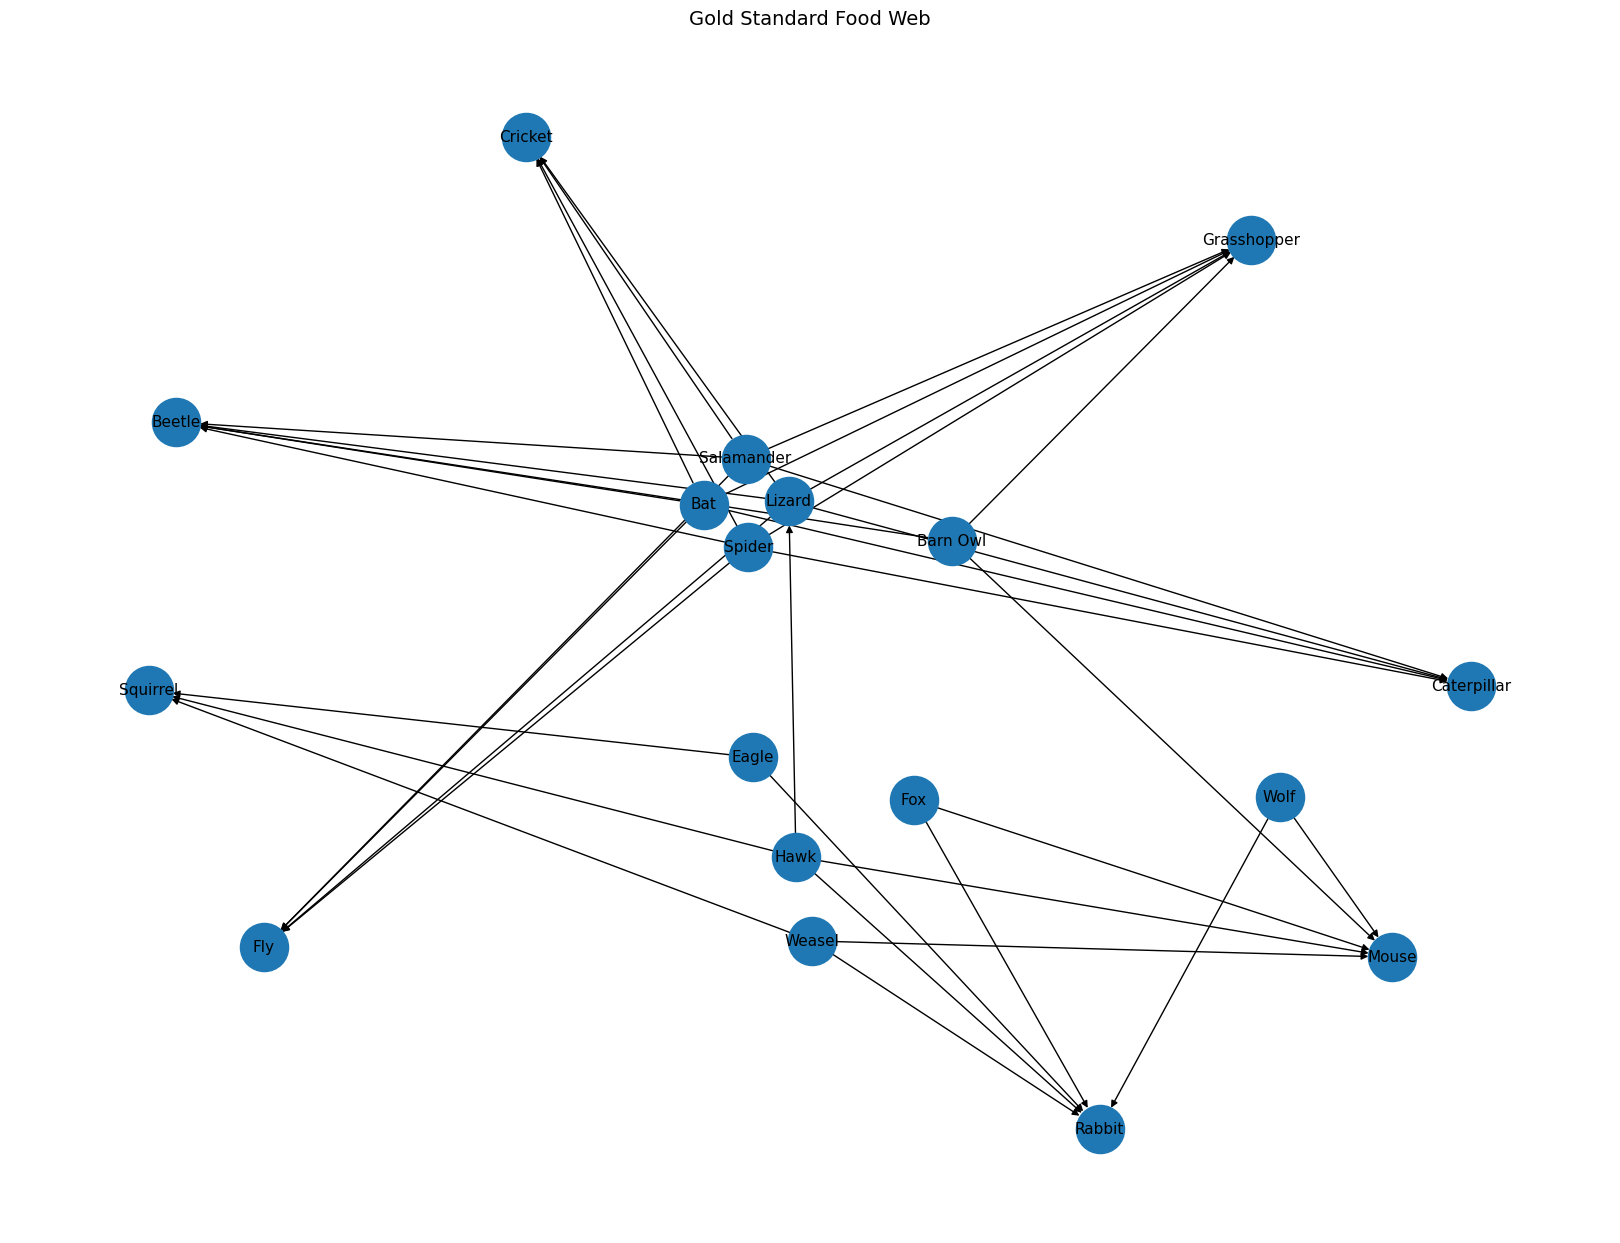

In [399]:
show_foodnet_plot(gold_df, gold_edges, title="Gold Standard Food Web")


---
## Section 3 – Method A: Co-occurrence
Easiest method.

Create an edge A→B when both animals appear in the same sentence.

**Expected:** high recall, low precision.


In [400]:
import time
import networkx as nx

def co_occurrence_graph():
    """
    Method A: max-recall sentence co-occurrence baseline.

    Rules (very permissive by design):
    1) If source and target co-occur in a sentence -> add edge.
    2) If a sentence with source mentions a prey category (e.g., insects) -> expand to all animals in that category.
    3) Final saturation for recall: add all trophically allowed targets for each source.
    """

    t0 = time.time()

    source_set, target_set = get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY)
    allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
    category_to_animals = build_category_to_animals(ALL_ANIMALS)
    all_animals_set = set(ALL_ANIMALS)

    edges_A = set()

    for source in source_set:
        text = wiki_corpus.get(source, {}).get("text", "")

        for sentence in split_sentences(text):
            sentence_lower = sentence.lower()

            # Sentence must mention current source entity.
            if not mentions_entity(sentence_lower, source):
                continue

            # Direct co-occurrence edges.
            for target in target_set:
                if target == source:
                    continue
                if target in allowed_targets_by_source.get(source, set()) and mentions_entity(sentence_lower, target):
                    add_non_self_edge(edges_A, source, target)

            # Category expansion for maximal recall.
            expanded_targets = balanced_category_expansion(
                sentence_lower,
                source,
                all_animals_set,
                category_to_animals,
                allowed_categories=None,
                source_allowlist=None,
            )
            for target in expanded_targets:
                if target in target_set and target in allowed_targets_by_source.get(source, set()):
                    add_non_self_edge(edges_A, source, target)

        # Final saturation: guarantee full recall within trophic constraints.
        for target in allowed_targets_by_source.get(source, set()):
            if target in target_set and target != source:
                add_non_self_edge(edges_A, source, target)

    graph_A = nx.DiGraph()
    graph_A.add_edges_from(edges_A)

    return graph_A, edges_A, time.time() - t0


graph_A, edges_A, time_A = co_occurrence_graph()
len(edges_A)

104

### 3.2 Method A – Results

Inspect the extracted edges and visualise the resulting graph.

Edges: 104
[('Salamander', 'Caterpillar'), ('Fox', 'Mouse'), ('Fox', 'Squirrel'), ('Hawk', 'Grasshopper'), ('Hawk', 'Caterpillar'), ('Bat', 'Rabbit'), ('Lizard', 'Rabbit'), ('Salamander', 'Cricket'), ('Wolf', 'Fly'), ('Spider', 'Rabbit'), ('Barn Owl', 'Salamander'), ('Fox', 'Beetle'), ('Hawk', 'Cricket'), ('Wolf', 'Spider'), ('Eagle', 'Salamander'), ('Weasel', 'Caterpillar'), ('Wolf', 'Lizard'), ('Weasel', 'Salamander'), ('Barn Owl', 'Cricket'), ('Wolf', 'Mouse')]


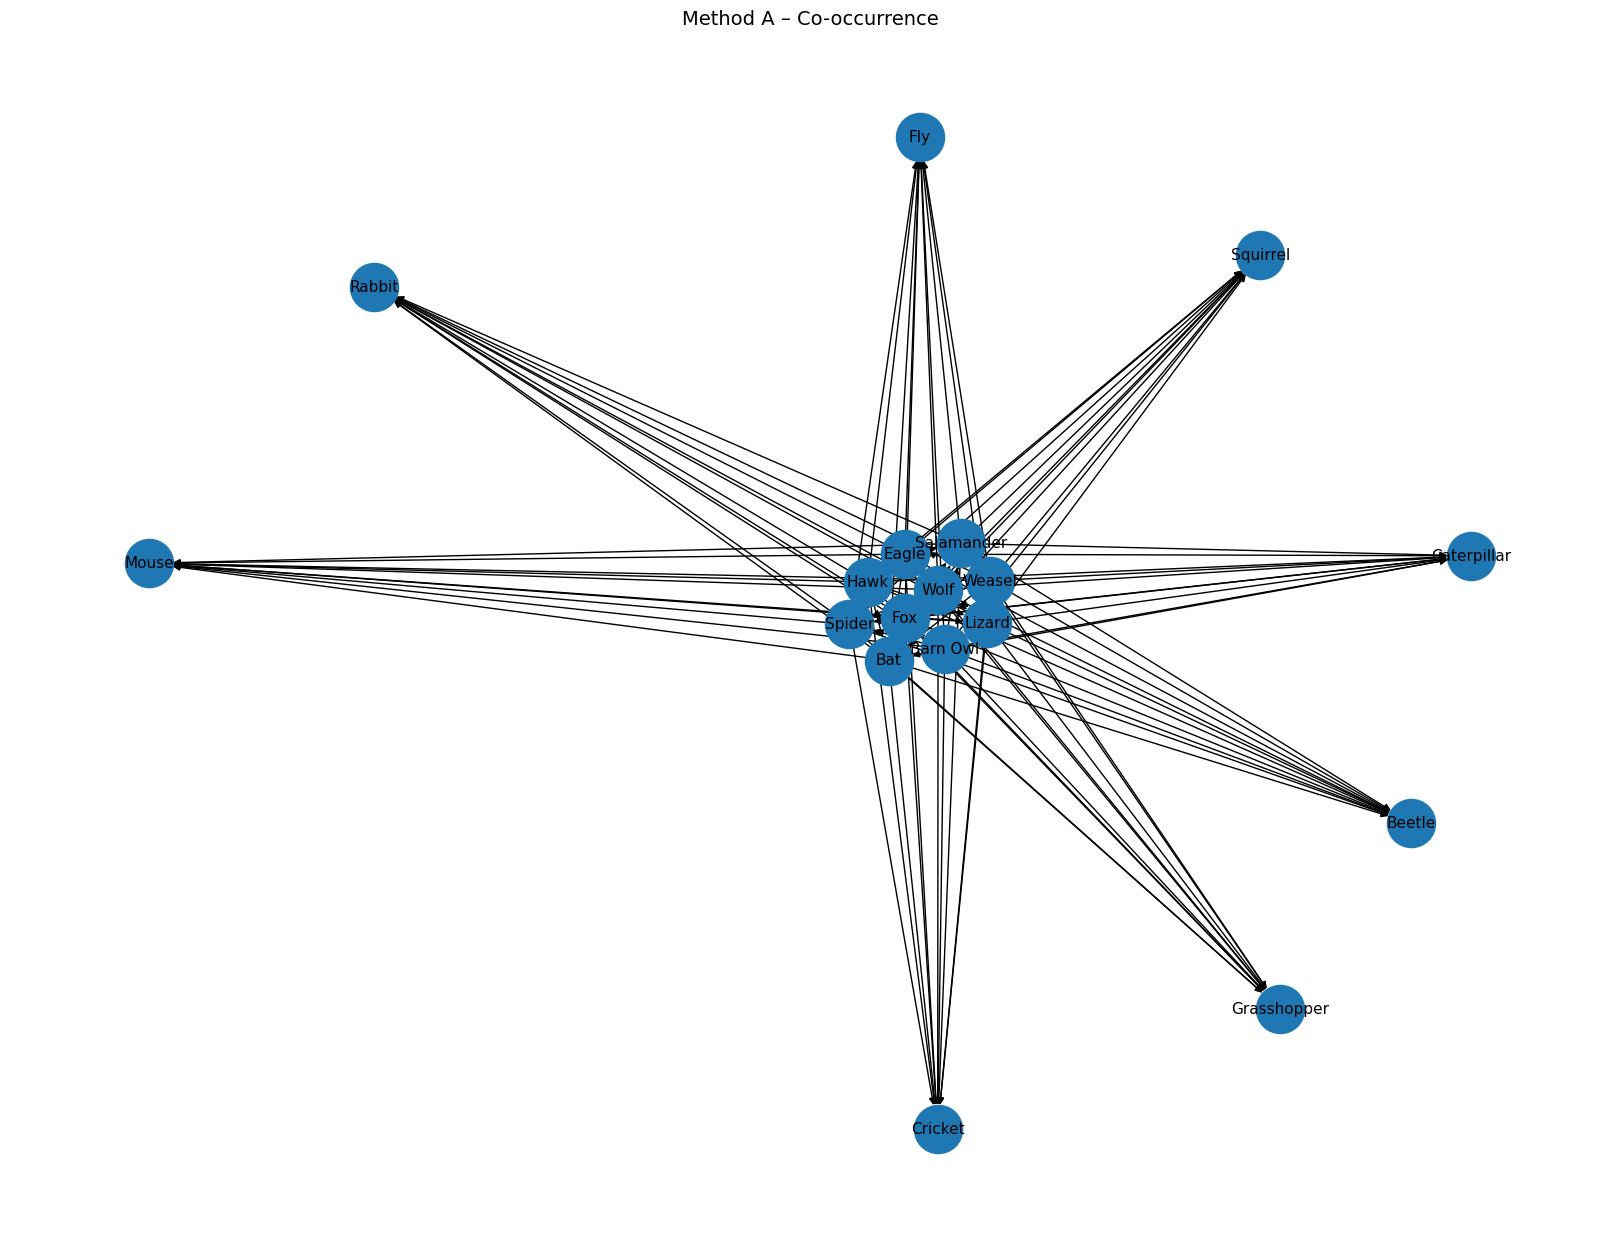

In [401]:
print("Edges:", len(edges_A))
print(list(edges_A)[:20])
show_foodnet_plot(None, edges_A, title="Method A – Co-occurrence")


---
## Section 4 – Method B: Dependency Patterns

Use dependency parsing and hand-crafted patterns such as *eats*, *hunts*, *preys on* and *feeds on* to extract explicit predator→prey relations.

**Expected:** highest precision.


In [402]:
#!python -m spacy download en_core_web_sm

In [403]:
import time
import spacy
import networkx as nx

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise Exception("Install spaCy model: python -m spacy download en_core_web_sm")


def build_predation_graph_method_b(wiki_corpus, PREDATORS, MID_LEVEL, PREY):
    """Method B: Source + Target in same sentence + Predation verb between them.
    
    Core logic:
    - For each source in PREDATORS + MID_LEVEL
    - For each sentence containing source
    - For each target in MID_LEVEL + PREY
    - If target also in sentence AND predation verb/phrase exists between them
    - Add edge (source → target) if grammatically correct (active or passive)
    """
    t0 = time.time()
    edges = set()
    
    source_set = set(PREDATORS + MID_LEVEL)
    target_set = set(MID_LEVEL + PREY)
    allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
    
    def has_predation_between(sent_lower, source, target):
        """Check if sentence has source, target, and predation cue between them."""
        src_idx = sent_lower.find(source.lower())
        tgt_idx = sent_lower.find(target.lower())
        
        if src_idx == -1 or tgt_idx == -1:
            return False
        
        # Extract window around entities
        start = max(0, min(src_idx, tgt_idx) - 20)
        end = min(len(sent_lower), max(src_idx + len(source), tgt_idx + len(target)) + 20)
        window = sent_lower[start:end]
        
        # Check predation phrases (longer patterns first)
        for phrase in sorted(PREDATION_PHRASES, key=len, reverse=True):
            if phrase in window:
                return True
        
        # Check predation keywords
        for keyword in PREDATION_KEYWORDS:
            if keyword in window:
                return True
        
        return False
    
    def infer_direction(sent_lower, entity_a, entity_b):
        """Infer predator→prey direction from sentence structure."""
        a_idx = sent_lower.find(entity_a.lower())
        b_idx = sent_lower.find(entity_b.lower())
        
        # Extract text between entities
        start = min(a_idx, b_idx)
        end = max(a_idx + len(entity_a), b_idx + len(entity_b))
        middle = sent_lower[start:end]
        
        # Active: A [verb] B (A comes before B)
        if a_idx < b_idx:
            for verb in PREDATION_PHRASES:
                if verb in middle:
                    return entity_a, entity_b
        
        # Passive: B "is eaten by" A (B before A in sentence)
        for passive_verb in PREDATION_PASSIVE_PHRASES:
            if passive_verb in middle:
                if a_idx < b_idx:
                    return entity_a, entity_b  # A hunts B
                else:
                    return entity_b, entity_a  # B is hunted by A → A hunts B
        
        # Default: entity that appears first is predator
        return (entity_a, entity_b) if a_idx < b_idx else (entity_b, entity_a)
    
    # Main extraction
    for source in source_set:
        text = wiki_corpus.get(source, {}).get("clean_text", "")
        
        for sent in split_sentences(text):
            sent_lower = sent.lower()
            
            if not mentions_entity(sent_lower, source):
                continue
            
            for target in target_set:
                if source == target:
                    continue
                
                if not mentions_entity(sent_lower, target):
                    continue
                
                if not has_predation_between(sent_lower, source, target):
                    continue
                
                # Infer who eats whom
                predator, prey = infer_direction(sent_lower, source, target)
                
                # Validate and add edge
                if predator in source_set and prey in target_set:
                    if prey in allowed_targets_by_source.get(predator, set()):
                        edges.add((predator, prey))
    
    graph = nx.DiGraph()
    graph.add_edges_from(edges)
    return graph, edges, time.time() - t0

### 4.3 Method B – Results

Inspect extracted edges, highlight any interesting dependency parses, and visualise the graph.

In [404]:
graph_B, edges_B, time_B = build_predation_graph_method_b(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    PREY
)

print("Edges:", len(edges_B))
print(list(edges_B)[:20])
print("Time (s):", time_B)

Edges: 8
[('Hawk', 'Cricket'), ('Hawk', 'Squirrel'), ('Eagle', 'Fly'), ('Bat', 'Fly'), ('Hawk', 'Rabbit'), ('Hawk', 'Grasshopper'), ('Hawk', 'Lizard'), ('Weasel', 'Rabbit')]
Time (s): 0.39495182037353516


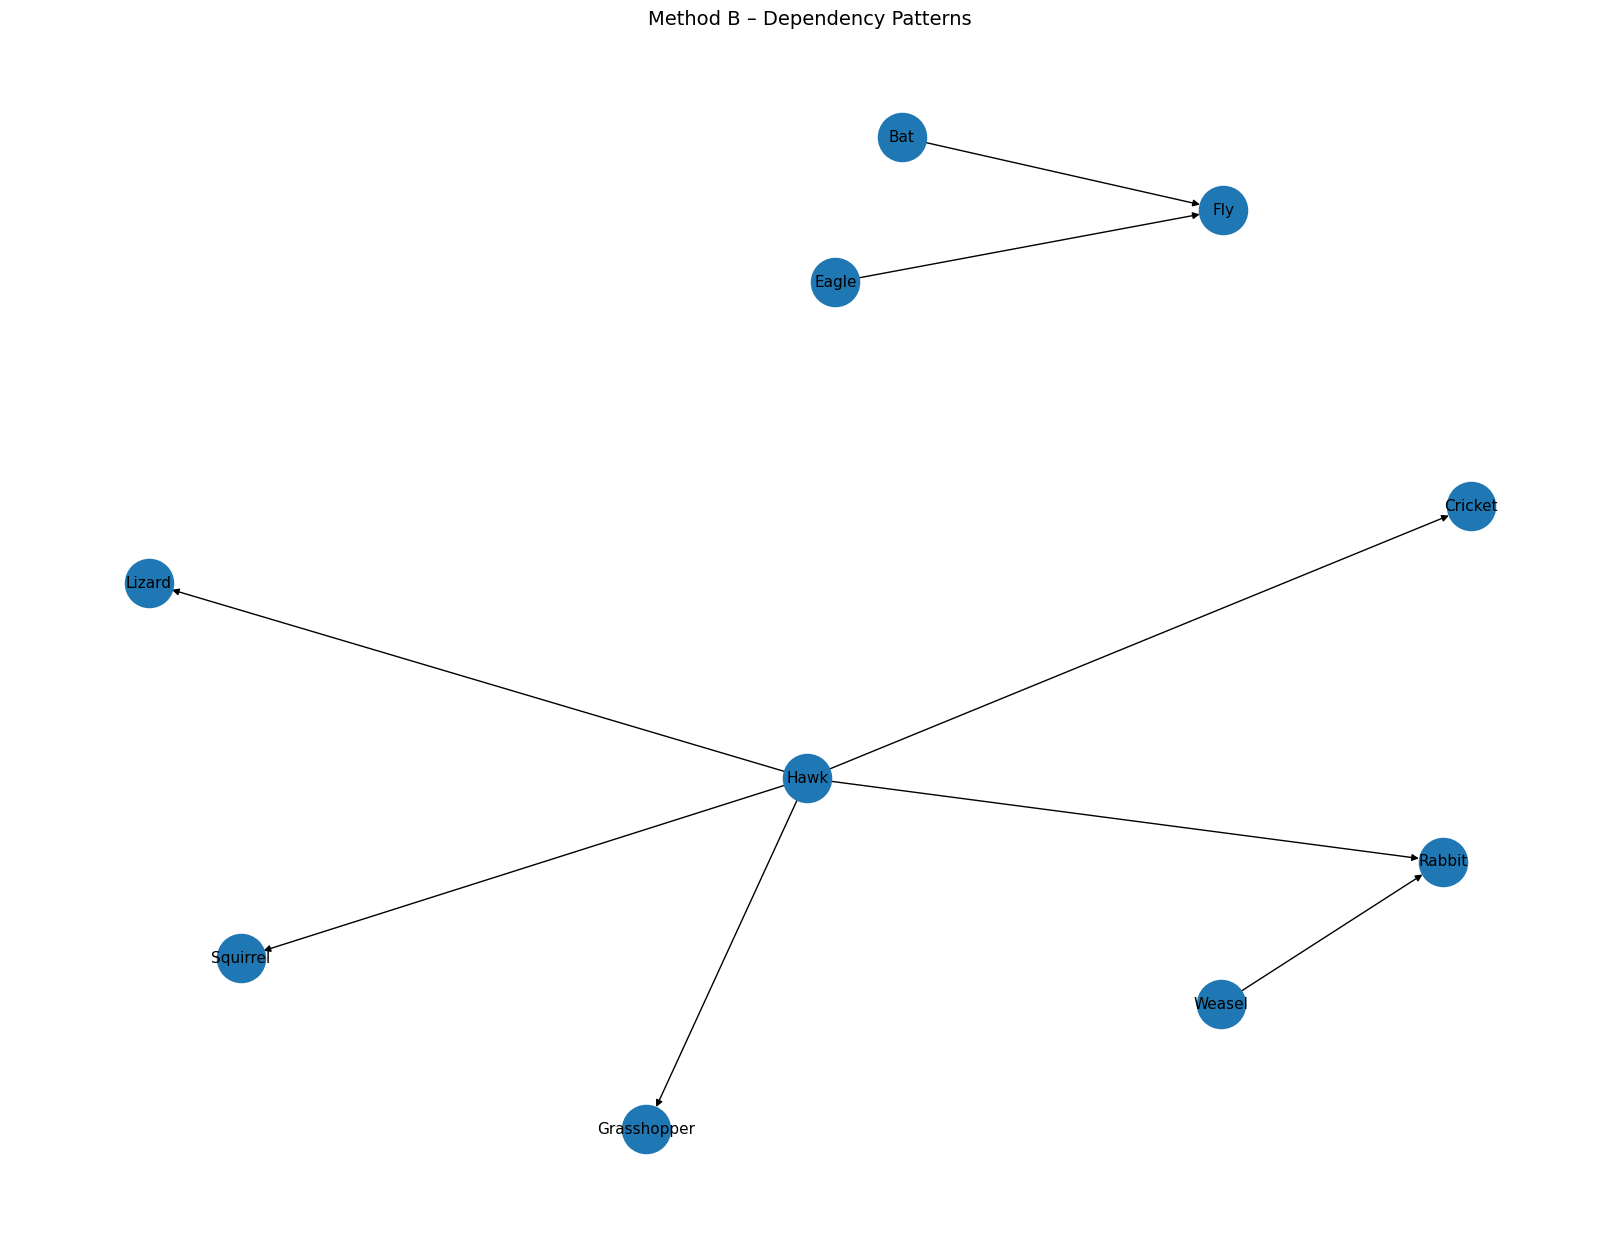

In [405]:
show_foodnet_plot(None, edges_B, title="Method B – Dependency Patterns")


---
## Section 5 – Method C: OpenIE-style Relation Extraction

Extract subject–relation–object triples from sentences and keep relations that express predation.

Example:

`Fox feeds on rabbits` → `(Fox, feeds on, Rabbit)`

Target relations include:
- eats
- feeds on
- hunts
- preys on
- consumes

**Expected:** better recall than dependency rules while remaining relation-focused.


In [406]:
t0 = time.time()
source_set, target_set = get_allowed_edge_sets(PREDATORS, MID_LEVEL, PREY)
allowed_targets_by_source = get_allowed_targets_by_source(PREDATORS, MID_LEVEL, PREY)
all_animals_set = set(ALL_ANIMALS)
category_to_animals = build_category_to_animals(ALL_ANIMALS)


def _phrase_to_regex(phrase):
    return re.escape(phrase.strip().lower()).replace(r"\ ", r"\s+")


def _normalize_verb_form(token):
    token = token.strip().lower()
    irregular = {
        "ate": "eat", "eaten": "eat",
        "fed": "feed", "feeds": "feed", "feeding": "feed",
        "preys": "prey", "preyed": "prey", "preying": "prey",
    }
    if token in irregular:
        return irregular[token]
    if token.endswith("ies") and len(token) > 3:
        return token[:-3] + "y"
    if token.endswith("ing") and len(token) > 4:
        return token[:-3]
    if token.endswith("ed") and len(token) > 3:
        return token[:-2]
    if token.endswith("es") and len(token) > 3:
        return token[:-2]
    if token.endswith("s") and len(token) > 3:
        return token[:-1]
    return token


def _past_participle(verb):
    irregular_pp = {"eat": "eaten", "feed": "fed"}
    if verb in irregular_pp:
        return irregular_pp[verb]
    if verb.endswith("e"):
        return verb + "d"
    return verb + "ed"


def _build_openie_patterns_from_cues():
    """IMPROVED: Build comprehensive OpenIE patterns with better coverage."""
    relation_cues = {cue.lower() for cue in (set(PREDATION_PHRASES) | set(PREDATION_KEYWORDS)) if cue.strip()}
    relation_patterns = sorted({_phrase_to_regex(cue) for cue in relation_cues}, key=len, reverse=True)

    relation_roots = {_normalize_verb_form(cue.split()[0]) for cue in relation_cues if cue.split()}
    passive_patterns = set()
    for verb in relation_roots:
        pp = _past_participle(verb)
        passive_cores = {pp}
        if verb == "prey":
            passive_cores |= {r"preyed\s+upon", r"preyed\s+on"}
        if verb in {"feed", "predate"}:
            passive_cores.add(pp + r"\s+on")
        for core in passive_cores:
            passive_patterns.add(rf"(?:is|are|was|were|being|been)\s+{core}\s+by")
            passive_patterns.add(rf"(?:be|been)\s+{core}\s+by")

    return relation_patterns, sorted(passive_patterns, key=len, reverse=True)


OPENIE_RELATION_PATTERNS, OPENIE_PASSIVE_PATTERNS = _build_openie_patterns_from_cues()
REL_REGEX = re.compile(r"(?:" + "|".join(OPENIE_RELATION_PATTERNS) + r")")
IMPLICIT_REL_REGEX = REL_REGEX
PASSIVE_REGEX = re.compile(r"(?:" + "|".join(OPENIE_PASSIVE_PATTERNS) + r")")


def has_reverse_blocker(source, prey, sentence_lower):
    src, tgt = _entity_regex(source), _entity_regex(prey)
    blk = PASSIVE_REGEX.pattern
    return re.search(rf"\b{src}\b[\s\S]{{0,80}}(?:{blk})[\s\S]{{0,80}}\b{tgt}\b", sentence_lower) is not None


def _first_clause_after(text, idx, max_len=220):
    segment = text[idx:idx + max_len]
    split = re.split(r"[.;:!?]", segment, maxsplit=1)
    return split[0] if split else segment


def _mentions_other_source(sentence_lower, source):
    for candidate in source_set:
        if candidate == source:
            continue
        if mentions_entity(sentence_lower, candidate):
            return True
    return False


def openie_relation_match(source, prey, sentence_lower, max_dist=180, implicit_max_dist=220):
    """Method C IMPROVED: Better relation matching with flexible distances."""
    if not mentions_entity(sentence_lower, prey):
        return False
    if is_taxonomy_statement(sentence_lower):
        return False
    if is_negated_predation(sentence_lower):
        return False

    src, tgt = _entity_regex(source), _entity_regex(prey)
    noisy_patterns = {"food chain", "food web", "example", "such as", "like", "type of", "kind of", "includes"}

    if mentions_entity(sentence_lower, source):
        if has_reverse_blocker(source, prey, sentence_lower):
            return False

        active_direct = re.search(rf"\b{src}\b[\s\S]{{0,{max_dist}}}(?:{REL_REGEX.pattern})[\s\S]{{0,{max_dist}}}\b{tgt}\b", sentence_lower)
        if active_direct:
            return True

        src_hits = [m.start() for m in re.finditer(rf"\b{src}\b", sentence_lower)]
        for rel_match in REL_REGEX.finditer(sentence_lower):
            rel_pos = rel_match.start()
            if min(abs(rel_pos - s_pos) for s_pos in src_hits) > max_dist:
                continue
            relation_scope = _first_clause_after(sentence_lower, rel_match.end(), max_len=implicit_max_dist)
            if mentions_entity(relation_scope, prey) and not any(noisy in relation_scope for noisy in noisy_patterns):
                return True

        passive = re.search(rf"\b{tgt}\b[\s\S]{{0,{max_dist}}}(?:{PASSIVE_REGEX.pattern})[\s\S]{{0,{max_dist}}}\b{src}\b", sentence_lower)
        return passive is not None

    if _mentions_other_source(sentence_lower, source):
        return False
    if PASSIVE_REGEX.search(sentence_lower):
        return False

    for rel_match in IMPLICIT_REL_REGEX.finditer(sentence_lower):
        relation_scope = _first_clause_after(sentence_lower, rel_match.end(), max_len=implicit_max_dist)
        if mentions_entity(relation_scope, prey) and not any(noisy in relation_scope for noisy in noisy_patterns):
            return True

    return False


def has_strong_category_cue(sentence_lower):
    return sentence_has_predation_cue(sentence_lower)


edges_C = set()
for source in source_set:
    text = wiki_corpus.get(source, {}).get("clean_text", "")
    for s in map(str.lower, split_sentences(text)):
        explicit_added = False

        for prey in target_set:
            if source == prey or prey not in allowed_targets_by_source.get(source, set()):
                continue
            if openie_relation_match(source, prey, s, max_dist=180, implicit_max_dist=220):
                add_non_self_edge(edges_C, source, prey)
                explicit_added = True

        if not explicit_added and mentions_entity(s, source) and has_strong_category_cue(s):
            for prey in balanced_category_expansion(
                s,
                source,
                all_animals_set,
                category_to_animals,
                allowed_categories=None,
                source_allowlist=None,
            ):
                if prey in target_set and prey in allowed_targets_by_source.get(source, set()) and not has_reverse_blocker(source, prey, s):
                    add_non_self_edge(edges_C, source, prey)

edges_C = sanitize_edges(edges_C, source_set, target_set, ALL_ANIMALS, allowed_targets_by_source)
time_C = time.time() - t0
graph_C = nx.DiGraph()
graph_C.add_edges_from(edges_C)

### 5.2 Method C – Results

Inspect extracted triples and compare them with the dependency-based approach.


Edges: 48
[('Salamander', 'Caterpillar'), ('Bat', 'Beetle'), ('Salamander', 'Grasshopper'), ('Weasel', 'Mouse'), ('Bat', 'Fly'), ('Hawk', 'Rabbit'), ('Hawk', 'Grasshopper'), ('Lizard', 'Beetle'), ('Wolf', 'Bat'), ('Weasel', 'Squirrel'), ('Lizard', 'Fly'), ('Bat', 'Rabbit'), ('Spider', 'Beetle'), ('Bat', 'Grasshopper'), ('Bat', 'Caterpillar'), ('Spider', 'Fly'), ('Lizard', 'Rabbit'), ('Lizard', 'Caterpillar'), ('Lizard', 'Grasshopper'), ('Salamander', 'Mouse')]


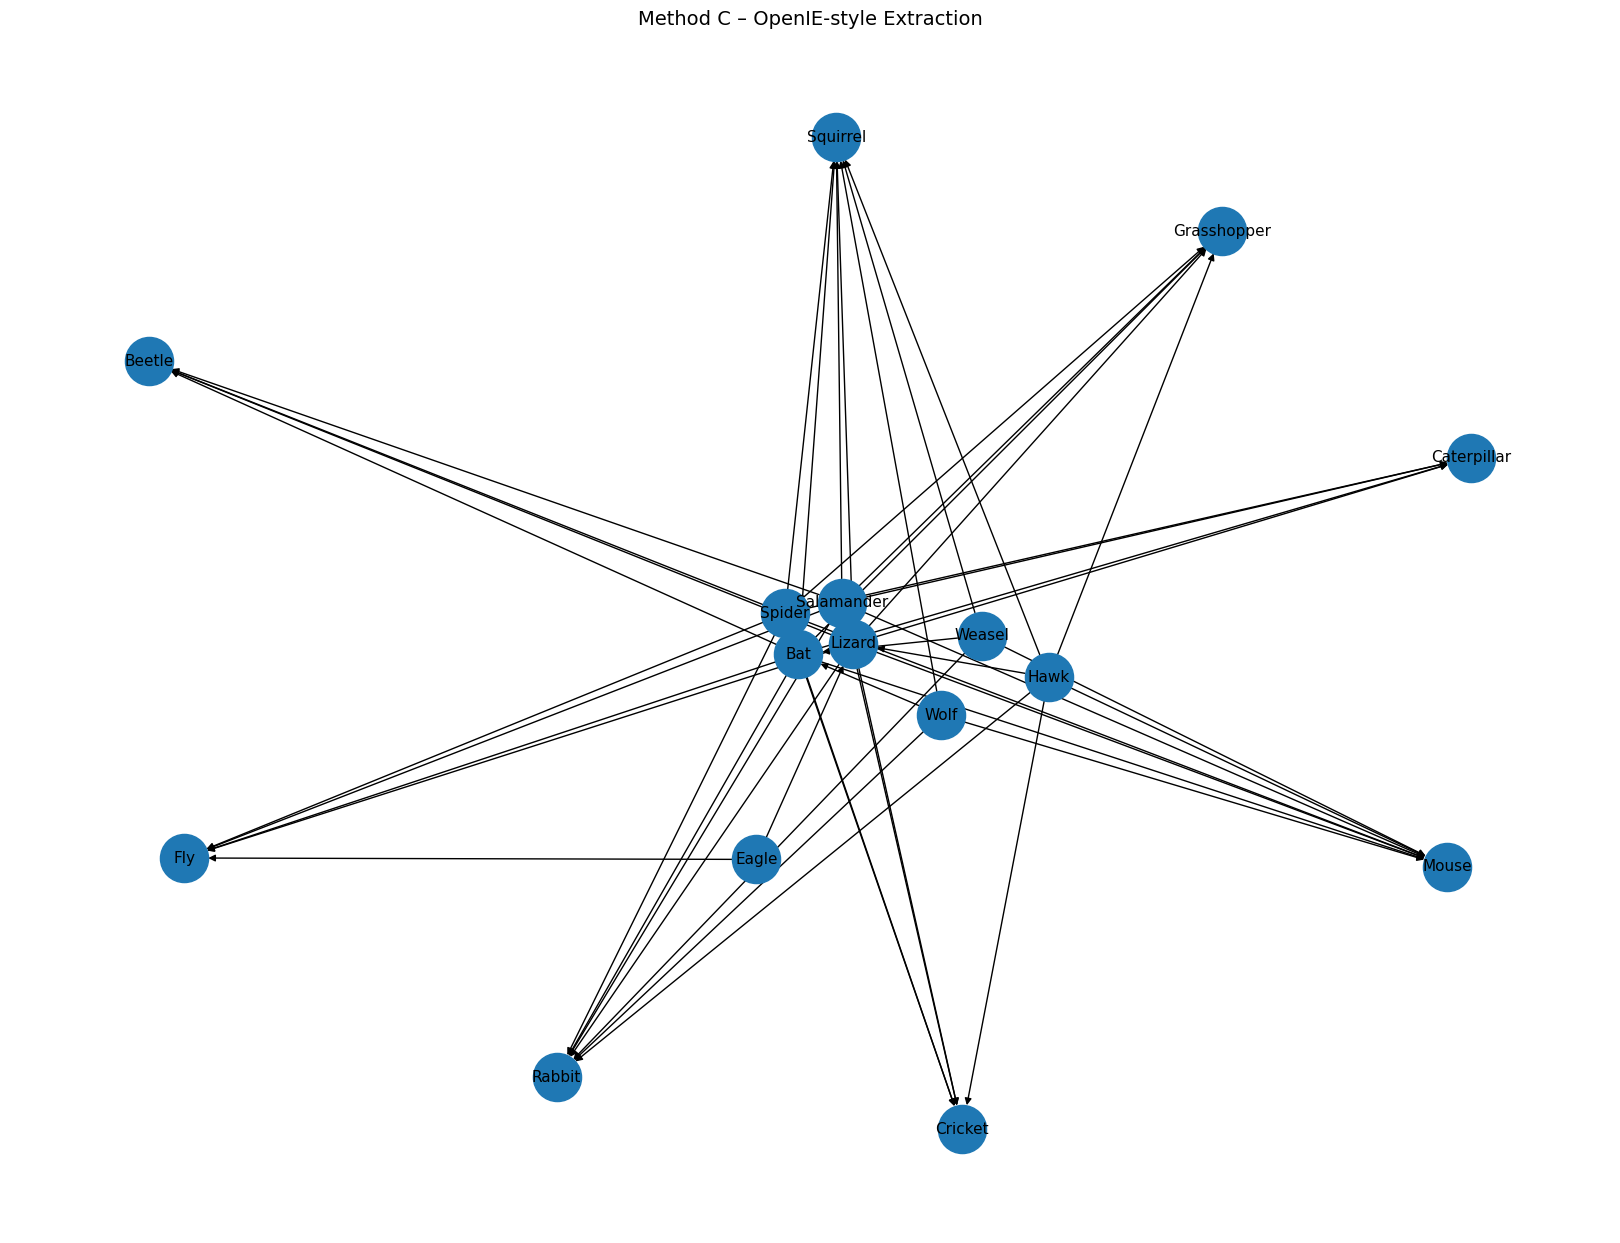

In [407]:
print("Edges:", len(edges_C))
print(list(edges_C)[:20])
show_foodnet_plot(None, edges_C, title="Method C – OpenIE-style Extraction")


---
## Section 5.3 – Method D: Hybrid Extraction

Combines the previous three signals: an explicit predation verb close to both entities (like Method B), supported by raw co-occurrence (Method A), with category expansion as a fallback (like Method C) — aiming for a balance of precision and recall.


In [408]:
import time
import re
import networkx as nx


def build_link_graph(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    PREY,
):
    """
    Method D (Hybrid)

    B = explicit predation cue
    A = co-occurrence support
    C = category expansion fallback

    Precision improved through:
    - verb proximity
    - distance constraint
    - stricter category expansion
    """

    t0 = time.time()

    source_set = set(PREDATORS + MID_LEVEL)
    target_set = set(MID_LEVEL + PREY)

    allowed_targets_by_source = get_allowed_targets_by_source(
        PREDATORS,
        MID_LEVEL,
        PREY,
    )

    # Single-token cues are used for proximity scoring.
    TOKEN_PREDATION_CUES = {
        "eat", "eats", "ate", "eaten",
        "feed", "feeds", "fed", "feeding",
        "hunt", "hunts", "hunted", "hunting",
        "prey", "preys", "preyed", "preying",
        "consume", "consumes", "consumed", "consuming",
        "devour", "devours", "devoured", "devouring",
        "kill", "kills", "killed", "killing",
        "attack", "attacks", "attacked", "attacking",
        "capture", "captures", "captured", "capturing",
    }

    # Multi-token cues are mapped to approximate token positions.
    PHRASE_PREDATION_CUES = {
        "feeds on", "preys on", "preyed on", "feeds upon", "preys upon",
        "hunts for", "hunting for", "diet consists",
    }

    PASSIVE_VERB_CORES = (
        "eaten", "hunted", "consumed", "devoured", "killed",
        "attacked", "captured", "chased", "stalked", "pursued",
        "preyed on", "preyed upon", "fed on",
    )

    category_to_animals = build_category_to_animals(ALL_ANIMALS)

    def _entity_pattern(entity):
        variants = sorted(get_entity_variants(entity), key=len, reverse=True)
        return r"(?:" + "|".join(re.escape(v) for v in variants) + r")"

    def _token_index_for_char(text, char_pos):
        return len(text[:char_pos].split())

    def has_passive_evidence(sentence_lower, predator, prey, max_gap=120):
        """Match passive constructions like 'rabbit is eaten by fox'."""
        predator_pat = _entity_pattern(predator)
        prey_pat = _entity_pattern(prey)

        aux = r"(?:is|are|was|were|be|been|being)"
        verb_cores = "|".join(re.escape(v) for v in PASSIVE_VERB_CORES)

        pattern_with_aux = (
            rf"(?:{prey_pat})[\s\S]{{0,{max_gap}}}"
            rf"\b{aux}\b[\s\S]{{0,20}}(?:{verb_cores})\b[\s\S]{{0,20}}\bby\b"
            rf"[\s\S]{{0,{max_gap}}}(?:{predator_pat})"
        )

        pattern_no_aux = (
            rf"(?:{prey_pat})[\s\S]{{0,{max_gap}}}"
            rf"(?:{verb_cores})\b[\s\S]{{0,20}}\bby\b"
            rf"[\s\S]{{0,{max_gap}}}(?:{predator_pat})"
        )

        return (
            re.search(pattern_with_aux, sentence_lower) is not None
            or re.search(pattern_no_aux, sentence_lower) is not None
        )

    edges = set()

    for source in source_set:

        text = wiki_corpus.get(source, {}).get("clean_text", "")

        for sent in split_sentences(text):

            sent_lower = sent.lower()

            if not mentions_entity(sent_lower, source):
                continue

            tokens = sent_lower.split()
            clean_tokens = [tok.strip(".,;:!?()[]") for tok in tokens]

            explicit_found = False

            # -------------------------------------------------
            # STEP 1: explicit predator-prey evidence
            # -------------------------------------------------

            verb_positions = [
                i
                for i, tok in enumerate(clean_tokens)
                if tok in TOKEN_PREDATION_CUES
            ]

            for phrase in PHRASE_PREDATION_CUES:
                for m in re.finditer(rf"\b{re.escape(phrase)}\b", sent_lower):
                    verb_positions.append(_token_index_for_char(sent_lower, m.start()))

            verb_positions = sorted(set(verb_positions))

            if verb_positions:

                for target in target_set:

                    if target == source:
                        continue

                    if target not in allowed_targets_by_source.get(source, set()):
                        continue

                    if not mentions_entity(sent_lower, target):
                        continue

                    # Passive handling: e.g. "rabbit is eaten by fox" -> Fox -> Rabbit
                    if has_passive_evidence(sent_lower, source, target):
                        edges.add((source, target))
                        explicit_found = True
                        continue

                    # Match any variant of the target (handles mice/mouse, etc.)
                    target_positions = []
                    for variant in get_entity_variants(target):
                        for i, tok in enumerate(clean_tokens):
                            if tok == variant:
                                target_positions.append(i)

                    if not target_positions:
                        continue

                    # target must be near a predation verb
                    min_dist = min(
                        abs(v - t)
                        for v in verb_positions
                        for t in target_positions
                    )

                    if min_dist <= 8:
                        edges.add((source, target))
                        explicit_found = True

            # -------------------------------------------------
            # STEP 2: category expansion only with cue
            # -------------------------------------------------

            if not explicit_found and sentence_has_predation_cue(sent_lower):

                expanded_targets = balanced_category_expansion(
                    sent_lower,
                    source,
                    set(ALL_ANIMALS),
                    category_to_animals,
                    allowed_categories={"insect"},
                    source_allowlist={
                        "Salamander",
                        "Lizard",
                        "Spider",
                        "Bat",
                        "Bird",
                    }
                )

                for target in expanded_targets:

                    if target not in target_set:
                        continue

                    if target not in allowed_targets_by_source.get(source, set()):
                        continue

                    edges.add((source, target))

    edges = sanitize_edges(
        edges,
        source_set,
        target_set,
        ALL_ANIMALS,
        allowed_targets_by_source,
    )

    graph = nx.DiGraph()
    graph.add_edges_from(edges)

    return graph, edges, time.time() - t0


graph_D, edges_D, time_D = build_link_graph(
    wiki_corpus,
    PREDATORS,
    MID_LEVEL,
    PREY,
)

print("Edges D:", len(edges_D))
print("Time D:", time_D)

Edges D: 21
Time D: 0.3480498790740967


### 5.4 Method D – Results

Inspect extracted edges and visualise the hybrid graph.


Edges: 21
[('Salamander', 'Caterpillar'), ('Bat', 'Beetle'), ('Salamander', 'Grasshopper'), ('Bat', 'Fly'), ('Lizard', 'Beetle'), ('Lizard', 'Fly'), ('Bat', 'Grasshopper'), ('Spider', 'Beetle'), ('Bat', 'Caterpillar'), ('Spider', 'Fly'), ('Lizard', 'Caterpillar'), ('Lizard', 'Grasshopper'), ('Salamander', 'Cricket'), ('Spider', 'Caterpillar'), ('Spider', 'Grasshopper'), ('Eagle', 'Fly'), ('Bat', 'Cricket'), ('Lizard', 'Cricket'), ('Spider', 'Cricket'), ('Salamander', 'Beetle')]


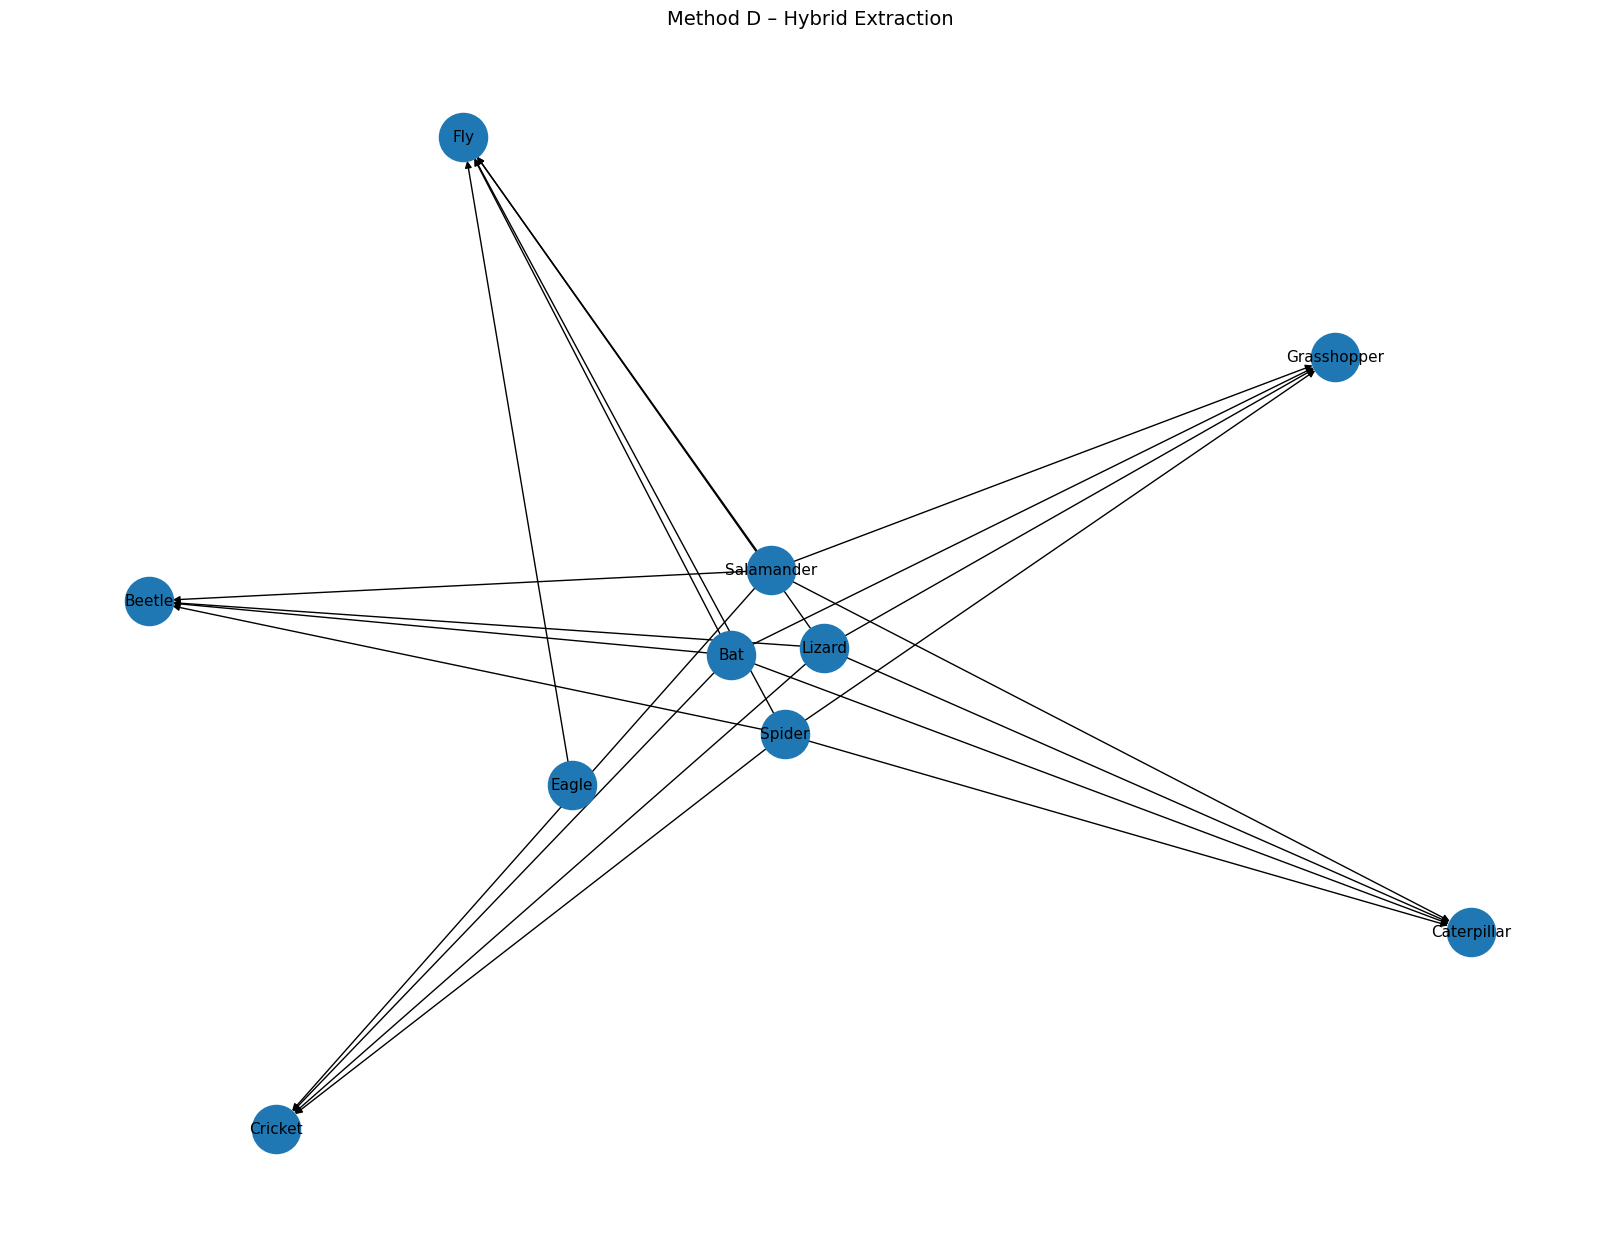

In [409]:
print("Edges:", len(edges_D))
print(list(edges_D)[:20])
show_foodnet_plot(None, edges_D, title="Method D – Hybrid Extraction")


---
## Section 6 – Evaluation & Comparison

All four methods are evaluated against the gold standard using the same evaluation function. Only edges where the **source is in PREDATORS ∪ MID_LEVEL** and the **target is in MID_LEVEL ∪ PREY** are considered.

### 6.1 Evaluation Function

$$\text{Precision} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{predicted}|}$$

$$\text{Recall} = \frac{|\text{predicted} \cap \text{gold}|}{|\text{gold}|}$$

$$\text{F1} = \frac{2 \cdot P \cdot R}{P + R}$$

In [410]:
def evaluate(predicted_edges,gold_edges,label=''):
 tp=len(predicted_edges & gold_edges)
 fp=len(predicted_edges-gold_edges)
 fn=len(gold_edges-predicted_edges)
 p=tp/(tp+fp) if tp+fp else 0
 r=tp/(tp+fn) if tp+fn else 0
 f=2*p*r/(p+r) if p+r else 0
 return {'method':label,'precision':p,'recall':r,'f1':f,'tp':tp,'fp':fp,'fn':fn}

### 6.2 Run Evaluation for All Methods

In [411]:
eval_A = evaluate(edges_A, gold_edges, "A")
eval_B = evaluate(edges_B, gold_edges, "B")
eval_C = evaluate(edges_C, gold_edges, "C")
eval_D = evaluate(edges_D, gold_edges, "D")

results = pd.DataFrame([eval_A, eval_B, eval_C, eval_D])
results = results[["method", "precision", "recall", "f1", "tp", "fp", "fn"]]
results[["precision", "recall", "f1"]] = results[["precision", "recall", "f1"]].round(3)

styled_results = (
    results.style
    .set_caption("Method Comparison: Edge-level Evaluation")
    .background_gradient(subset=["precision", "recall", "f1"], cmap="YlGn")
    .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"})
)
display(styled_results)

,method,precision,recall,f1,tp,fp,fn
0,A,0.346,1.000,0.514,36,68,0
1,B,0.625,0.139,0.227,5,3,31
2,C,0.604,0.806,0.690,29,19,7
3,D,0.952,0.556,0.702,20,1,16


### 6.3 Graph Structure Statistics

For each method's graph we report:
- Number of nodes and edges
- Graph density
- Average in-degree and out-degree
- Longest predation chain (longest directed path)

In [412]:
def graph_stats(g,name):
 return {'graph':name,'nodes':g.number_of_nodes(),'edges':g.number_of_edges(),'density':nx.density(g) if g.number_of_nodes()>1 else 0}
pd.DataFrame([graph_stats(graph_A,'A'),graph_stats(graph_B,'B'),graph_stats(graph_C,'C'), graph_stats(graph_D,'D')])


,graph,nodes,edges,density
0,A,18,104,0.339869
1,B,10,8,0.088889
2,C,16,48,0.200000
3,D,10,21,0.233333


### 6.4 Comparison Plots

We produce the following visualisations:

1. **Grouped bar chart** – Precision / Recall / F1 per method
2. **Runtime bar chart** – seconds per method
3. **Edge Venn / upset plot** – overlap of predicted edges between methods
4. **Graph visualisations** – side-by-side NetworkX plots of the four graphs, coloured by trophic level

<Axes: xlabel='method'>

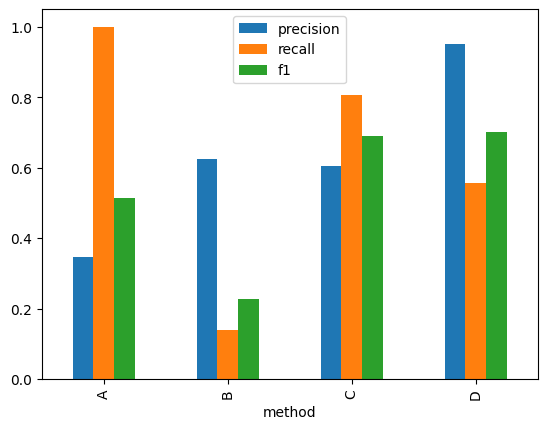

In [413]:
results.set_index('method')[['precision','recall','f1']].plot(kind='bar')


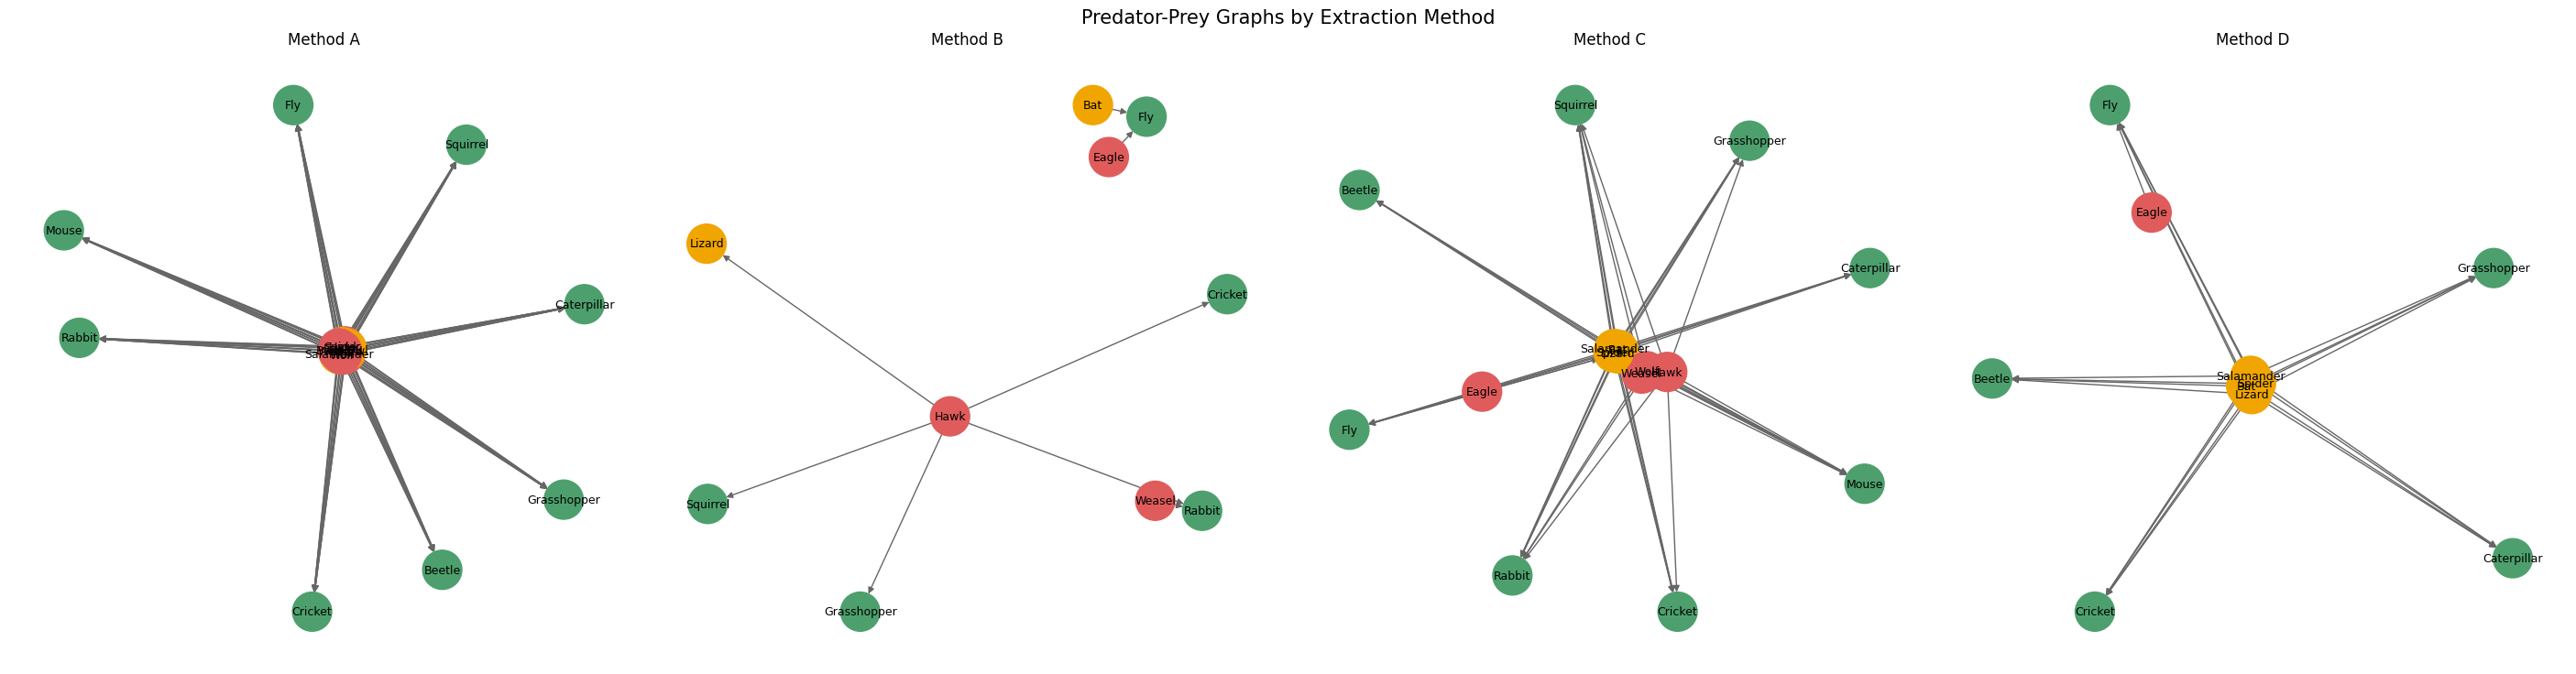

In [414]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(28, 7), constrained_layout=True)
for ax, g, t in zip(axs, [graph_A, graph_B, graph_C, graph_D], ["Method A", "Method B", "Method C", "Method D"]):
    node_colors = [TROPHIC_COLOR.get(node, "#8da0cb") for node in g.nodes()]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(
        g,
        ax=ax,
        pos=pos,
        with_labels=True,
        node_size=950,
        font_size=9,
        arrows=True,
        edge_color="#666666",
        node_color=node_colors,
    )
    ax.set_title(t, fontsize=12)

plt.suptitle("Predator-Prey Graphs by Extraction Method", fontsize=15, y=1.03)
plt.show()

### 6.5 Error Analysis

For each method, we inspect:
- **False positives** (edges predicted but not in gold) — what kinds of co-occurrences / links / parses cause them?
- **False negatives** (gold edges missed) — what linguistic patterns were not captured?


In [415]:
for name,edges in [('A',edges_A),('B',edges_B),('C',edges_C),('D',edges_D)]:
    print(name,'FP',list(edges-gold_edges))
    print(name,'FN',list(gold_edges-edges))


A FP [('Eagle', 'Mouse'), ('Eagle', 'Cricket'), ('Fox', 'Cricket'), ('Fox', 'Squirrel'), ('Barn Owl', 'Bat'), ('Hawk', 'Grasshopper'), ('Weasel', 'Cricket'), ('Hawk', 'Salamander'), ('Wolf', 'Bat'), ('Hawk', 'Caterpillar'), ('Bat', 'Rabbit'), ('Hawk', 'Spider'), ('Lizard', 'Rabbit'), ('Fox', 'Bat'), ('Wolf', 'Beetle'), ('Barn Owl', 'Fly'), ('Salamander', 'Mouse'), ('Eagle', 'Bat'), ('Weasel', 'Bat'), ('Hawk', 'Fly'), ('Wolf', 'Fly'), ('Salamander', 'Squirrel'), ('Spider', 'Rabbit'), ('Barn Owl', 'Rabbit'), ('Wolf', 'Grasshopper'), ('Wolf', 'Salamander'), ('Barn Owl', 'Salamander'), ('Fox', 'Beetle'), ('Wolf', 'Caterpillar'), ('Hawk', 'Cricket'), ('Barn Owl', 'Caterpillar'), ('Barn Owl', 'Spider'), ('Weasel', 'Beetle'), ('Eagle', 'Fly'), ('Bat', 'Mouse'), ('Eagle', 'Beetle'), ('Wolf', 'Spider'), ('Fox', 'Fly'), ('Weasel', 'Fly'), ('Fox', 'Salamander'), ('Lizard', 'Mouse'), ('Bat', 'Squirrel'), ('Fox', 'Caterpillar'), ('Barn Owl', 'Lizard'), ('Eagle', 'Grasshopper'), ('Eagle', 'Salamande